# Violence Detection CGN Model Builder

## Dependencies Import

In [ ]:
!pip install optuna

In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import optuna

## Config

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {device}")

Device: cuda


In [ ]:
CLASSES = ['assault', 'fighting', 'shooting', 'robbery', 'normal_event']

ZIP_PATH = '/content/drive/MyDrive/Colab Notebooks/dataset/violence_dataset.zip'
EXTRACT_PATH = '/content/dataset'
SAVE_DIR = '/content/drive/MyDrive/GCN_Models_Output'

RANDOM_SEED = 67
BATCH_SIZE = 64

TRIAL_EPOCH = 50
TRIAL_N = 5

TRAIN_EPOCH = 500

In [ ]:
if not os.path.exists(EXTRACT_PATH):
  print("Extracting Dataset...")
  with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
  print("Dataset has been extracted!")
else:
  print("Dataset has already been extracted previously")

Dataset has already been extracted previously


In [ ]:
os.makedirs(SAVE_DIR, exist_ok=True)

## EDA

In [ ]:
data_counts = {}
sample_shape = None

In [ ]:
for cls in CLASSES:
  folder = os.path.join(EXTRACT_PATH, cls)
  if os.path.exists(folder):
    files = [f for f in os.listdir(folder) if f.endswith('.npy')]
    data_counts[cls] = len(files)

    if len(files) > 0 and sample_shape is None:
      sample_path = os.path.join(folder, files[0])
      sample_data = np.load(sample_path)
      sample_shape = sample_data.shape
  else:
    data_counts[cls] = 0

In [ ]:
print(f".npy Dimension Sample (C, T, V, M): {sample_shape}")

.npy Dimension Sample (C, T, V, M): (3, 100, 17, 3)


/tmp/ipykernel_7659/4213805863.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(data_counts.keys()), y=list(data_counts.values()), palette="viridis")


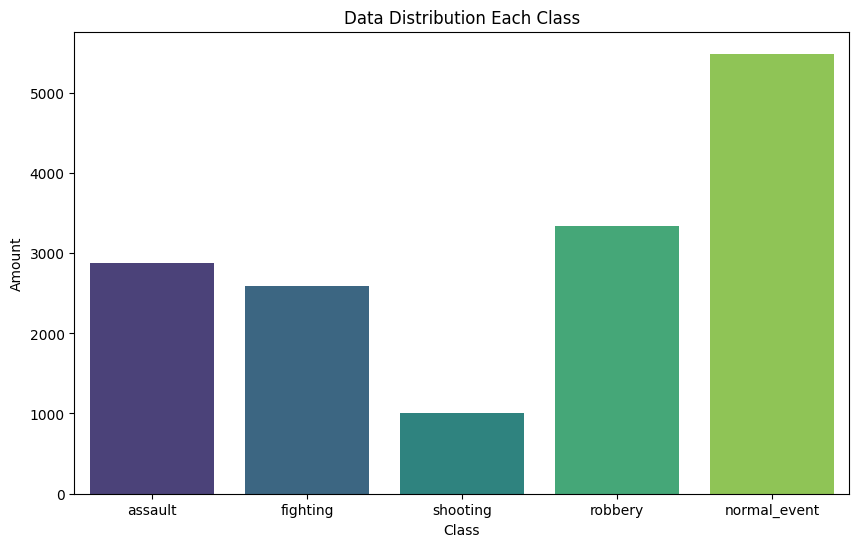

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=list(data_counts.keys()), y=list(data_counts.values()), palette="viridis")
plt.title("Data Distribution Each Class")
plt.ylabel("Amount")
plt.xlabel("Class")
plt.show()

In [ ]:
print("\nFile Amount Detail:")
for k, v in data_counts.items():
  print(f"- {k}: {v} files")


File Amount Detail:
- assault: 2871 files
- fighting: 2586 files
- shooting: 1002 files
- robbery: 3332 files
- normal_event: 5489 files


## Load Dataset

In [ ]:
class ViolencePoseDataset(Dataset):
  def __init__(self, file_paths, labels):
    self.file_paths = file_paths
    self.labels = labels

  def __len__(self):
    return len(self.file_paths)

  def __getitem__(self, idx):
    # Load data: Shape awal (3, 100, 17, 3) -> (C, T, V, M)
    data = np.load(self.file_paths[idx]).astype(np.float32)

    return torch.tensor(data), torch.tensor(self.labels[idx], dtype=torch.long)

In [ ]:
all_files = []
all_labels = []

class_map = {cls_name: i for i, cls_name in enumerate(CLASSES)}

for cls in CLASSES:
  folder = os.path.join(EXTRACT_PATH, cls)
  if os.path.exists(folder):
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith('.npy')]
    all_files.extend(files)
    all_labels.extend([class_map[cls]] * len(files))

X_train, X_temp, y_train, y_temp = train_test_split(all_files, all_labels, test_size=0.30, random_state=RANDOM_SEED, stratify=all_labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(1/3), random_state=RANDOM_SEED, stratify=y_temp)

In [ ]:
print(f"Total Dataset: {len(all_files)}")
print(f"Train: {len(X_train)} (70%) | Val: {len(X_val)} (20%) | Test: {len(X_test)} (10%)")

Total Dataset: 15280
Train: 10696 (70%) | Val: 3056 (20%) | Test: 1528 (10%)


In [ ]:
train_loader = DataLoader(ViolencePoseDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(ViolencePoseDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(ViolencePoseDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

## Model Architecture

In [ ]:
raw_edges = [
  (0, 1), (0, 2), (1, 3), (2, 4),
  (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
  (11, 12), (5, 11), (6, 12),
  (11, 13), (13, 15), (12, 14), (14, 16)
]

In [ ]:
def get_adjacency_matrix():
  A = np.zeros((17, 17))
  for i, j in raw_edges:
    A[i, j] = 1
    A[j, i] = 1
  A = A + np.eye(17)

  # Normalize
  D = np.diag(np.sum(A, axis=1) ** (-0.5))
  A_norm = np.dot(np.dot(D, A), D)
  return torch.tensor(A_norm, dtype=torch.float32).to(device)

In [ ]:
A = get_adjacency_matrix()

In [ ]:
# GCN Spatial Graph Block

class GraphConv(nn.Module):
  def __init__(self, in_channels, out_channels, num_vertices=17, adaptive=True):
    super().__init__()
    self.adaptive = adaptive

    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    self.bn = nn.BatchNorm2d(out_channels)
    self.relu = nn.ReLU()

    # Learnable Adjacency Matrix (Memungkinkan graf untuk berevolusi/belajar)
    if self.adaptive:
      # Diinisialisasi dengan nilai sangat kecil agar mulai dari graf asli
      self.PA = nn.Parameter(torch.randn(num_vertices, num_vertices) * 1e-4)

    # Residual Connection / Skip Connection
    if in_channels != out_channels:
      self.down_sample = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=1),
        nn.BatchNorm2d(out_channels)
      )
    else:
      self.down_sample = lambda x: x # Identity function jika ukuran channel sama

  def forward(self, x, A):
    residual = self.down_sample(x)

    x = self.conv(x)

    if self.adaptive:
      # Graf yang dinamis = Graf asli + Graf yang dipelajari (PA)
      A_dynamic = A + self.PA
      x = torch.einsum('nctv,vw->nctw', x, A_dynamic)
    else:
      x = torch.einsum('nctv,vw->nctw', x, A)

    x = self.bn(x)

    return self.relu(x + residual)

In [ ]:
# Temporal Attention Mechanism

class TemporalAttention(nn.Module):
  def __init__(self, hidden_dim):
    super().__init__()
    # Layer linear untuk menghitung bobot setiap frame waktu
    self.attention = nn.Sequential(
      nn.Linear(hidden_dim, hidden_dim // 2),
      nn.Tanh(),
      nn.Linear(hidden_dim // 2, 1)
    )

  def forward(self, lstm_out):
    # lstm_out shape: (Batch, Time_frames, Hidden_dim)

    # Hitung skor atensi untuk setiap frame
    attn_scores = self.attention(lstm_out) # (Batch, Time, 1)
    attn_weights = torch.softmax(attn_scores, dim=1) # Softmax sepanjang dimensi waktu

    # Kalikan frame dengan bobotnya, lalu jumlahkan
    context_vector = torch.sum(attn_weights * lstm_out, dim=1) # (Batch, Hidden_dim)
    return context_vector, attn_weights

In [ ]:
class GCN_LSTM(nn.Module):
  def __init__(self, num_classes=5, in_channels=3, hidden_gcn=64, hidden_lstm=256, lstm_layers=2, dropout=0.5):
    super().__init__()
    self.V = 17

    # Spatial Extraction
    self.gcn_blocks = nn.ModuleList([
      GraphConv(in_channels, hidden_gcn, self.V),
      GraphConv(hidden_gcn, hidden_gcn * 2, self.V),
      GraphConv(hidden_gcn * 2, hidden_gcn * 4, self.V) # Channel membesar di layer dalam
    ])

    self.tcn = nn.Sequential(
      nn.Conv1d(hidden_gcn * 4, hidden_gcn * 4, kernel_size=3, padding=1),
      nn.BatchNorm1d(hidden_gcn * 4),
      nn.ReLU()
    )

    # LSTM Block
    self.lstm = nn.LSTM(
      input_size=hidden_gcn * 4,
      hidden_size=hidden_lstm,
      num_layers=lstm_layers,
      batch_first=True,
      dropout=dropout if lstm_layers > 1 else 0.0,
      bidirectional=True # Bidirectional melihat masa lalu & masa depan frame
    )

    self.attn = TemporalAttention(hidden_lstm * 2)

    self.fc = nn.Sequential(
      nn.Linear(hidden_lstm * 2, hidden_lstm),
      nn.ReLU(),
      nn.Dropout(dropout),
      nn.Linear(hidden_lstm, num_classes)
    )

  def forward(self, x, A):
    # Input: (N, C, T, V, M)
    N, C, T, V, M = x.size()

    # --- EARLY RESHAPE ---
    x = x.permute(0, 4, 1, 2, 3).contiguous()
    x = x.view(N * M, C, T, V)

    # --- SPATIAL GCN PROCESSING ---
    for gcn in self.gcn_blocks:
      x = gcn(x, A) # Memutar x melalui 3 lapis GCN adaptif

    # Spatial Pooling: meratakan fitur 17 sendi (N*M, C_out, T, 17) -> (N*M, C_out, T)
    x = x.mean(dim=-1)

    # --- TEMPORAL CONVOLUTION (TCN) ---
    x = self.tcn(x)

    # --- LSTM PROCESSING ---
    # Persiapan LSTM (N*M, T, C_out)
    x = x.permute(0, 2, 1).contiguous()

    lstm_out, _ = self.lstm(x)

    # --- TEMPORAL ATTENTION ---
    # Alih-alih mengambil frame terakhir, kita biarkan mekanisme atensi memilih frame terbaik
    x, _ = self.attn(lstm_out) # x shape: (N*M, hidden_lstm * 2)

    # --- LATE POOLING (MENGAMBIL INTERAKSI M ORANG) ---
    x = x.view(N, M, -1)
    x = torch.max(x, dim=1)[0] # (N, hidden_lstm * 2)

    # --- KLASIFIKASI AKHIR ---
    out = self.fc(x)
    return out

## Hyper Parameter Tuning

In [ ]:
def objective(trial, model_class, A, train_loader, val_loader, epochs=100):
  # Hyperparameters
  lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
  hidden_gcn = trial.suggest_categorical("hidden_gcn", [32, 64, 128])
  hidden_lstm = trial.suggest_categorical("hidden_lstm", [128, 256, 512])
  lstm_layers = trial.suggest_int("lstm_layers", 1, 3)
  dropout = trial.suggest_float("dropout", 0.3, 0.6)
  weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

  model = model_class(
    num_classes=len(CLASSES),
    in_channels=3,
    hidden_gcn=hidden_gcn,
    hidden_lstm=hidden_lstm,
    lstm_layers=lstm_layers,
    dropout=dropout
  ).to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

  best_val_loss = float('inf')
  best_val_acc = 0.0
  best_train_loss = float('inf')
  best_train_acc = 0.0
  best_epoch = 0

  patience = 15
  patience_counter = 0

  for epoch in tqdm(range(epochs), desc=f"Trial Attempt #{trial.number}", leave=False):
    model.train()
    model.train()
    train_loss = 0
    train_preds = []
    train_targets = []

    for batch_x, batch_y in train_loader:
      batch_x, batch_y = batch_x.to(device), batch_y.to(device)
      optimizer.zero_grad()
      outputs = model(batch_x, A)
      loss = criterion(outputs, batch_y)
      loss.backward()
      optimizer.step()

      train_loss += loss.item()
      preds = torch.argmax(outputs, dim=1).cpu().numpy()
      train_preds.extend(preds)
      train_targets.extend(batch_y.cpu().numpy())

    train_loss /= len(train_loader)
    train_acc = accuracy_score(train_targets, train_preds)

    model.eval()
    val_loss = 0
    val_preds = []
    val_targets = []

    with torch.no_grad():
      for batch_x, batch_y in val_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        outputs = model(batch_x, A)
        loss = criterion(outputs, batch_y)
        val_loss += loss.item()

        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        val_preds.extend(preds)
        val_targets.extend(batch_y.cpu().numpy())

    val_loss /= len(val_loader)
    val_acc = accuracy_score(val_targets, val_preds)

    trial.report(val_loss, epoch)
    if trial.should_prune():
      raise optuna.exceptions.TrialPruned()

    if val_loss < best_val_loss:
      best_val_loss = val_loss
      best_val_acc = val_acc
      best_train_loss = train_loss
      best_train_acc = train_acc
      best_epoch = epoch + 1
      patience_counter = 0
    else:
      patience_counter += 1
      if patience_counter >= patience:
        break

  print(f"\n[Trial #{trial.number} Finished | Stopped in Epoch {epoch+1} | Best Epoch: {best_epoch}]")
  print(f" -> Train Loss: {best_train_loss:.4f} | Train Acc: {best_train_acc:.4f}")
  print(f" -> Val Loss:   {best_val_loss:.4f} | Val Acc:   {best_val_acc:.4f}")
  print("-" * 50)

  return best_val_loss

In [ ]:
print("--- Tuning GCN-LSTM ---")

--- Tuning GCN-LSTM ---


In [ ]:
study_gcn_lstm = optuna.create_study(direction="minimize")

[I 2026-05-06 00:07:36,466] A new study created in memory with name: no-name-a9028285-9db4-429c-850a-3adc566c908a


In [ ]:
study_gcn_lstm.optimize(lambda trial: objective(trial, GCN_LSTM, A, train_loader, val_loader, epochs=TRIAL_EPOCH), n_trials=TRIAL_N)

[W 2026-05-06 00:07:42,550] Trial 0 failed with parameters: {'lr': 0.00023824617777213838, 'hidden_gcn': 64, 'hidden_lstm': 512, 'lstm_layers': 2, 'dropout': 0.45889744170867774, 'weight_decay': 0.0002813466127410409} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_7659/1003197669.py", line 1, in <lambda>
    study_gcn_lstm.optimize(lambda trial: objective(trial, GCN_LSTM, A, train_loader, val_loader, epochs=TRIAL_EPOCH), n_trials=TRIAL_N)
                                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_7659/2037596987.py", line 46, in objective
    train_loss += loss.item()
                  ^^^^^^^^^^^
KeyboardInterrupt
[W 2026-05-06 00:07:42,552] Trial 0 failed with value None.


KeyboardInterrupt: 

In [ ]:
print("=== Best Params ===")
print(study_gcn_lstm.best_params)

## Model Training

In [ ]:
# best_params = study_gcn_lstm.best_params
best_params = {'lr': 0.0003491826067812087, 'hidden_gcn': 128, 'hidden_lstm': 128, 'lstm_layers': 2, 'dropout': 0.4888916045569277, 'weight_decay': 1.208164612391245e-05}

In [ ]:
save_path = os.path.join(SAVE_DIR, "GCN_LSTM_best.pth")

In [ ]:
model = GCN_LSTM(
    num_classes=len(CLASSES),
    in_channels=3,
    hidden_gcn=best_params.get('hidden_gcn'),
    hidden_lstm=best_params.get('hidden_lstm'),
    lstm_layers=best_params.get('lstm_layers'),
    dropout=best_params.get('dropout')
  ).to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=best_params.get('lr'), weight_decay=best_params.get('weight_decay'))
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)

In [ ]:
best_val_loss = float('inf')
best_val_acc = 0
best_val_f1 = 0

In [ ]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

In [ ]:
epoch_pbar = tqdm(range(TRAIN_EPOCH), desc="Training Progress")

for epoch in epoch_pbar:
  model.train()
  train_loss = 0
  train_preds = []
  train_labels = []

  for batch_x, batch_y in train_loader:
    batch_x, batch_y = batch_x.to(device), batch_y.to(device)
    optimizer.zero_grad()
    outputs = model(batch_x, A)
    loss = criterion(outputs, batch_y)
    loss.backward()
    optimizer.step()
    train_loss += loss.item()

    preds = torch.argmax(outputs, dim=1).cpu().numpy()
    train_preds.extend(preds)
    train_labels.extend(batch_y.cpu().numpy())

  train_loss /= len(train_loader)
  train_acc = accuracy_score(train_labels, train_preds)

  # Validation
  model.eval()
  val_loss = 0
  all_preds = []
  all_labels = []
  with torch.no_grad():
    for batch_x, batch_y in val_loader:
      batch_x, batch_y = batch_x.to(device), batch_y.to(device)
      outputs = model(batch_x, A)
      loss = criterion(outputs, batch_y)
      val_loss += loss.item()

      preds = torch.argmax(outputs, dim=1).cpu().numpy()
      all_preds.extend(preds)
      all_labels.extend(batch_y.cpu().numpy())

  val_loss /= len(val_loader)
  val_acc = accuracy_score(all_labels, all_preds)
  val_f1 = f1_score(all_labels, all_preds, average='weighted')

  history['train_loss'].append(train_loss)
  history['train_acc'].append(train_acc)
  history['val_loss'].append(val_loss)
  history['val_acc'].append(val_acc)

  scheduler.step(val_loss)

  # Simpan Model Terbaik
  if val_loss < best_val_loss:
    best_val_loss = val_loss
    best_val_acc = val_acc
    best_val_f1 = val_f1
    torch.save(model.state_dict(), save_path)

  epoch_pbar.set_postfix({
    'T_Loss': f"{train_loss:.4f}",
    'T_Acc': f"{train_acc:.4f}",
    'V_Loss': f"{val_loss:.4f}",
    'V_Acc': f"{val_acc:.4f}"
  })

  if (epoch+1) % 50 == 0 or epoch == 0:
    tqdm.write(f"Epoch [{epoch+1}/{TRAIN_EPOCH}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

Training Progress:   0%|          | 1/500 [00:51<7:08:55, 51.57s/it, T_Loss=1.3509, T_Acc=0.4317, V_Loss=1.2616, V_Acc=0.4820]

Epoch [1/500] | Train Loss: 1.3509 | Train Acc: 0.4317 | Val Loss: 1.2616 | Val Acc: 0.4820 | Val F1: 0.4420


Training Progress:  10%|█         | 50/500 [42:53<6:25:58, 51.46s/it, T_Loss=0.0482, T_Acc=0.9864, V_Loss=0.6340, V_Acc=0.8570]

Epoch [50/500] | Train Loss: 0.0482 | Train Acc: 0.9864 | Val Loss: 0.6340 | Val Acc: 0.8570 | Val F1: 0.8564


Training Progress:  20%|██        | 100/500 [1:25:46<5:43:08, 51.47s/it, T_Loss=0.0107, T_Acc=0.9977, V_Loss=0.7662, V_Acc=0.8639]

...

Epoch [400/500] | Train Loss: 0.0032 | Train Acc: 0.9989 | Val Loss: 0.7797 | Val Acc: 0.8730 | Val F1: 0.8725


Training Progress:  90%|█████████ | 450/500 [6:26:02<42:54, 51.49s/it, T_Loss=0.0110, T_Acc=0.9988, V_Loss=0.7970, V_Acc=0.8691]

Epoch [450/500] | Train Loss: 0.0110 | Train Acc: 0.9988 | Val Loss: 0.7970 | Val Acc: 0.8691 | Val F1: 0.8685


Training Progress: 100%|██████████| 500/500 [7:08:57<00:00, 51.47s/it, T_Loss=0.0029, T_Acc=0.9993, V_Loss=0.7756, V_Acc=0.8730]

Epoch [500/500] | Train Loss: 0.0029 | Train Acc: 0.9993 | Val Loss: 0.7756 | Val Acc: 0.8730 | Val F1: 0.8725


In [ ]:
print(f"Model saved in {save_path}")

print("Best Train Result:")
print(f"Val Loss: {best_val_loss:.4f}")
print(f"Val Acc: {best_val_acc:.4f}")
print(f"Val F1: {best_val_f1:.4f}")

Model saved in /content/drive/MyDrive/GCN_Models_Output/GCN_LSTM_best.pth
Best Train Result:
Val Loss: 0.5809
Val Acc: 0.8037
Val F1: 0.8044


### Train Result

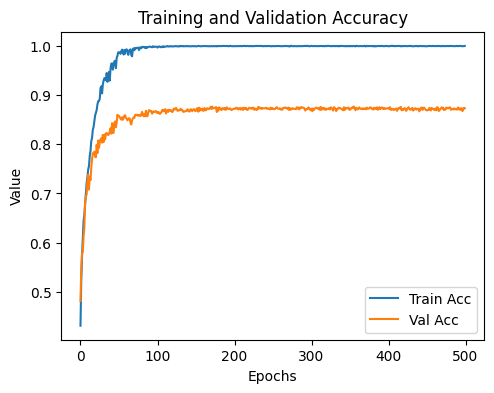

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()

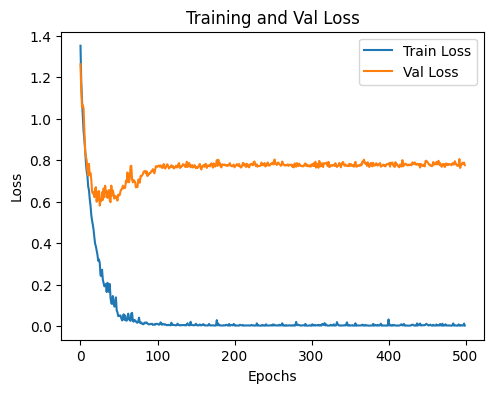

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Training and Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

## Model Test

In [ ]:
model.load_state_dict(torch.load(save_path))
model.eval()

GCN_LSTM(
  (gcn_blocks): ModuleList(
    (0): GraphConv(
      (conv): Conv2d(3, 128, kernel_size=(1, 1), stride=(1, 1))
      (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (down_sample): Sequential(
        (0): Conv2d(3, 128, kernel_size=(1, 1), stride=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): GraphConv(
      (conv): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1))
      (bn): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (down_sample): Sequential(
        (0): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1))
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): GraphConv(
      (conv): Conv2d(256, 512, kernel_size=(1, 1), stride=(1, 1))
      (bn): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, t

In [ ]:
test_loss = 0
test_preds = []
test_targets = []

In [ ]:
with torch.no_grad():
  for batch_x, batch_y in tqdm(test_loader, desc="Test Dataset Evaluation"):
    batch_x, batch_y = batch_x.to(device), batch_y.to(device)
    outputs = model(batch_x, A)
    loss = criterion(outputs, batch_y)
    test_loss += loss.item()

    preds = torch.argmax(outputs, dim=1).cpu().numpy()
    test_preds.extend(preds)
    test_targets.extend(batch_y.cpu().numpy())

test_loss /= len(test_loader)
test_acc = accuracy_score(test_targets, test_preds)
test_f1 = f1_score(test_targets, test_preds, average='weighted')

Test Dataset Evaluation: 100%|██████████| 24/24 [00:02<00:00,  9.16it/s]


In [ ]:
print("Test Result:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc: {test_acc:.4f}")
print(f"Test F1: {test_f1:.4f}")

Test Result:
Test Loss: 0.5460
Test Acc: 0.8115
Test F1: 0.8119


### Test Result

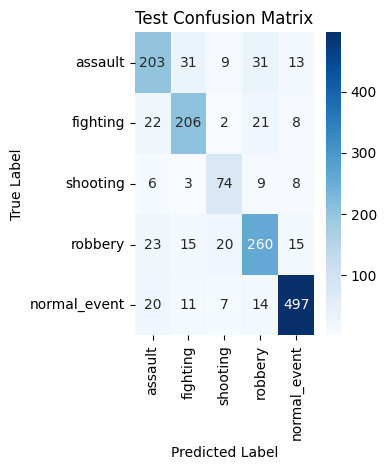

In [ ]:
plt.subplot(1, 2, 2)
cm = confusion_matrix(test_targets, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Test Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()